# [1교시]

### confusion matrix
- 실제 정답인데 정답이라고 맞힌 경우
- 실제 오답인데 오답이라고 맞힌 경우
- 실제 오답인데 정답이라고 틀린 경우
- 실제 정답인데 오답이라고 틀린 경우


| 구분                  | 예측 오답 (Negative) | 예측 정답 (Positive) |
|-----------------------|----------------------|----------------------|
| 실제 오답 (Negative) | TP                   | FN                   |
| 실제 정답 (Positive) | FP                   | TN                   |

- ACCURACY : (TP + TN) / (TP + FN + FP + TN)

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}$$

- PRECISION(정밀도) : 모델이 긍정이라고 예측한 것들 중에서 실제 긍정인 비율() : 틀리지 않는 것이 중요 (스팸메일 분류)

$$\text{Precision}=\frac{TP}{TP+FP}$$

- Recall(재현율) : 실제 정답중에서 모델이 정답이라고 찾아낸 비율 (암 진단)

$$\text{Recall}=\frac{TP}{TP+FN}$$

- F1_SCORE : 정밀도 재현율은 트레이드오프 관계가 있는 경우가 많음 : 조화평균을 사용한다

$${F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

# [2교시]

($F_\beta$) : 재현율(Recall)을 정밀도(Precison) 보다 얼마나 더 중요하게 여기는지 나타내는 계수

$$ F_{\beta} = (1 + \beta^{2}) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^{2} \cdot \text{Precision} + \text{Recall}} $$
- $beta$ = 2 : 재현율이 정밀도보다 2배 더 중요하게 본다(놓치면 안되는 상황(잘못예측해도 어느정도 상쇄되는 상황))
- $beta$ = 0.5 : 재현율이 정밀도보다 2배 더 중요하게 본다( 잘못 예측하면 안되는 상황(놓쳐도 된다는 상황))

In [1]:
re = 0.9 ;pe = 0.4
f1 = 2*re*pe/(re+pe)
print(f1)

0.5538461538461539


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 모델이 1이라고 예측할 확률 (0.0~1.0)
y_true = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
# 임계값 설정
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
threshold = 0.5
# 예측 결과 계산
y_pred = (y_scores >= threshold).astype(int)
conf_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()

conf_matrix, tn, fp, fn, tp

(array([[3, 2],
        [3, 2]]),
 3,
 2,
 3,
 2)

In [4]:
# 정밀도
precisionscore = precision_score(y_true, y_pred)
print(precisionscore, 3/6)
# 재현율
recallscore = recall_score(y_true, y_pred)
print(recallscore, 2/5)

0.5 0.5
0.4 0.4


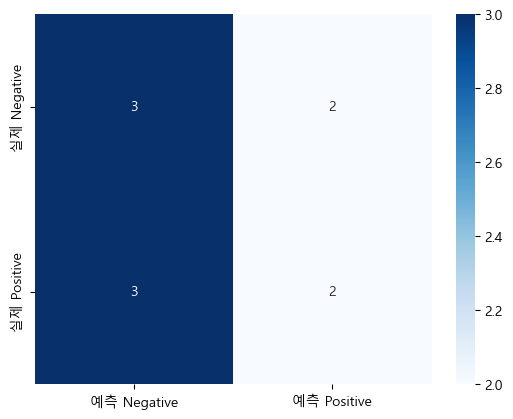

In [5]:
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels= ['예측 Negative','예측 Positive'],
            yticklabels= ['실제 Negative','실제 Positive']
            )
plt.show()

# [3교시]

In [18]:
y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
threshold = 0.8  # 확실한 경우만 1로 보겠음... 
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

threshold = 0.3  # 대략적으로 비슷하면 1로 보겠음...
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

1.0 0.5
0.5714285714285714 1.0


실제정답 [0 0 0 1 1 0 0 1 1 0]
[0.4        0.44444444 0.57142857 0.66666667 0.8        1.
 1.         1.         1.         1.        ]
 [1.   1.   1.   1.   1.   1.   0.75 0.5  0.25 0.  ] 
 [0.1  0.2  0.3  0.35 0.4  0.6  0.7  0.8  0.9 ]


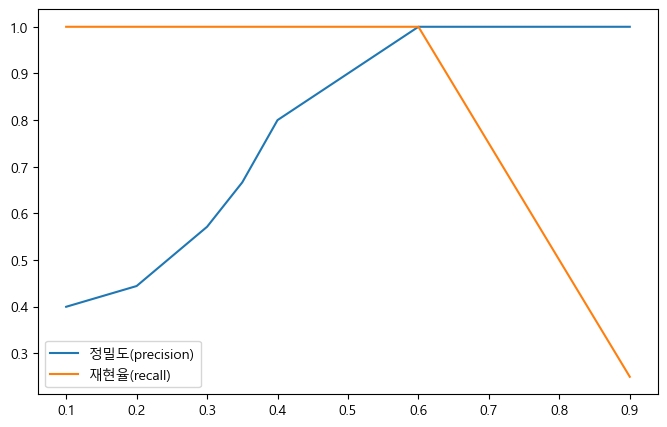

In [19]:
from sklearn.metrics import precision_recall_curve
precision, recall, threshold = precision_recall_curve(y_true, x_prob)
print('실제정답', y_true)
print(f'{precision}\n {recall} \n {threshold}')
plt.figure(figsize= (8, 5))
plt.plot(threshold, precision[:-1], label = '정밀도(precision)')
plt.plot(threshold, recall[:-1], label = '재현율(recall)')
plt.legend()
plt.show()

- ROC(ROC Curve)
    - 기준선을 바꿔가면서 진짜 정답을 맞추는 비율 TPR -y축

    $$TPR = \frac{TP}{TP + FN}$$
    
    - 오답을 정답이라고 판단한 비율 FPR -x축

    $$FPR = \frac{FP}{FP + TN}$$


- AUC(Area Under the Curve)
    - 

[0.         0.16666667 0.16666667 0.66666667 1.        ] 
 [0.   0.25 1.   1.   1.  ] 
 [inf 0.9 0.6 0.3 0.2]
AUC(곡선아래 면적) 0.8542


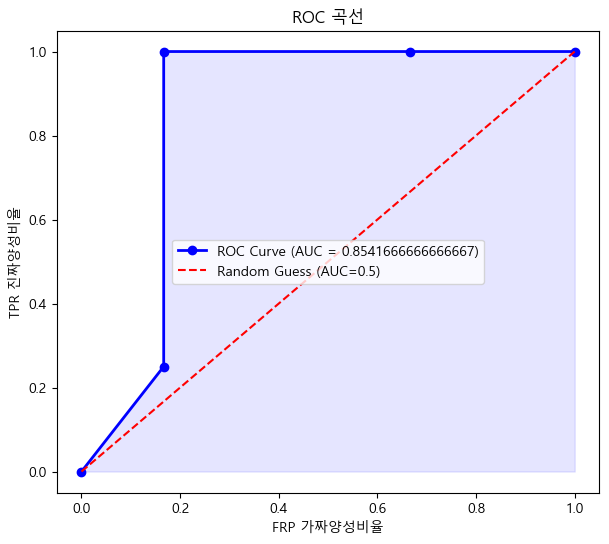

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.9, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])

roc_curve(y_true,x_prob)
fpr, tpr, threshold = roc_curve(y_true,x_prob)
print(fpr,'\n', tpr,'\n', threshold)
roc_acu = roc_auc_score(y_true,x_prob)
print(f'AUC(곡선아래 면적) {roc_acu:.4f}')

# ROC 곡선
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='blue',linewidth=2,marker='o', label=f'ROC Curve (AUC = {roc_acu})') 
plt.plot([0,1],[0,1] ,color='red', linestyle='--' , label = 'Random Guess (AUC=0.5)')
plt.fill_between(fpr ,tpr, color='blue', alpha=0.1)  # 곡선아래 면적
plt.title('ROC 곡선')
plt.xlabel('FRP 가짜양성비율')
plt.ylabel('TPR 진짜양성비율')
plt.legend()
plt.show()

좋은 모델일수록 1.0부분이 볼록하게 올라간다!

# [4교시]

- 암진단처럼 재현율이 우선인 모델을 만들자
    - 1. 결과값에 threshold를 낮게 부여해서 recall 값을 올리는 threshold를 찾는 방법
    - 2. 학습할 때 암환자를 놓치는 경우에 패널티를 강하게 부여(손실함수를 수정 BCEWithlogitLoss의 파라메터 조정)

In [84]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,roc_curve,roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [89]:
from collections import Counter
data = load_breast_cancer()
X = data.data
y = 1-data.target  # 악성을 1,  양성(정상) 0
print(Counter(y))
# 데이터 분리 클래스비율 유지  8:2
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y, random_state=42, test_size=0.2)
# 스케일링
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) 
x_test = scaler.transform(x_test) 

# 텐서로 변경
x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

Counter({np.int64(0): 357, np.int64(1): 212})


In [108]:
#  신경망 제작
# hidden (x_dim, 32)
# hidden (32, 16)
# hidden (16, 1)
# 활성함수 ReLu

class BreastModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,1)
        )
    def forward(self, x):
        return self.network(x)

def print_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ps = precision_score(y_true, y_pred)
    rs = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f'confusion_matrix : \n {cm}')
    print(f'precision_score : {ps:.4f}')
    print(f' ****recall_score**** : {rs:.4f}')
    print(f'f1_score : {f1:.4f}')

# [5교시]

In [109]:
torch.manual_seed(42)
model = BreastModel(x_train_t.shape[-1])
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=0.01)
epochs=100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_predict = model(x_train_t).squeeze(1)
    loss = criterion(y_predict,y_train_t)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = model(x_test_t)    
    props = torch.sigmoid(logits).numpy()


threshold = 0.00001  # 0.00001 ~ 0.0001
preds_05 = (props >= threshold).astype(int)
print_metrics(y_test,preds_05)

confusion_matrix : 
 [[48 24]
 [ 0 42]]
precision_score : 0.6364
 ****recall_score**** : 1.0000
f1_score : 0.7778


In [110]:
# nn.BCEWithLogitsLoss  pos_weight 값이 높으면  1을 0으로 놓쳤을때 더 강한 패널티를 부여( 높은 손실점수)
torch.manual_seed(42)
# 암환자(1) 놓치는 것에 대해 정상(0) 보다 10배의 가중치(패널티)를 부여
weight_for_positive = torch.tensor([305.0])
model_weighted = BreastModel(x_train_t.shape[-1])
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=weight_for_positive)
optim_weighted = Adam(model_weighted.parameters(), lr=0.01)

epochs=100
for epoch in range(epochs):
    optim_weighted.zero_grad()
    y_predict = model_weighted(x_train_t).squeeze(1)
    loss = criterion_weighted(y_predict,y_train_t)
    loss.backward()
    optim_weighted.step()

with torch.no_grad():
    logits = model_weighted(x_test_t)    
    props = torch.sigmoid(logits).numpy()

threshold = 0.5
preds_05 = (props >= threshold).astype(int)
print_metrics(y_test,preds_05)    

confusion_matrix : 
 [[58 14]
 [ 0 42]]
precision_score : 0.7500
 ****recall_score**** : 1.0000
f1_score : 0.8571


[0.         0.         0.         0.01388889 0.01388889 0.19444444
 0.19444444 1.        ] 
 [0.         0.61904762 0.92857143 0.92857143 0.97619048 0.97619048
 1.         1.        ] 
 [       inf 1.         0.99889225 0.99680424 0.995093   0.55521345
 0.5052002  0.12722942]
AUC(곡선아래 면적) 0.9947


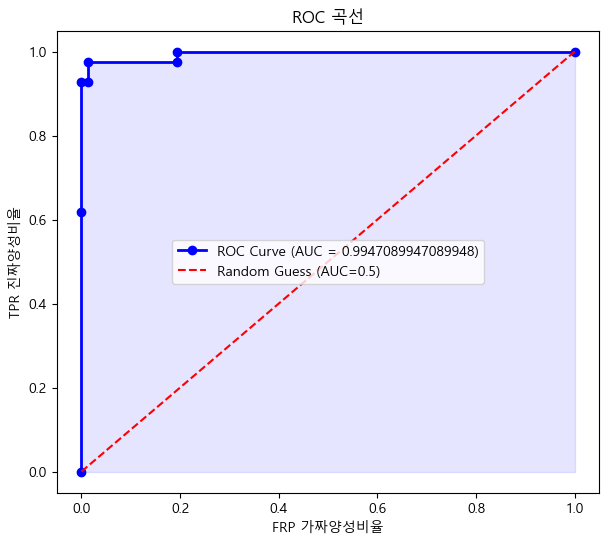

In [111]:
fpr,tpr,threshold = roc_curve(y_test,props)
print(fpr,'\n', tpr,'\n', threshold)
roc_acu = roc_auc_score(y_test,props)
print(f'AUC(곡선아래 면적) {roc_acu:.4f}')

# ROC 곡선
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='blue',linewidth=2,marker='o', label=f'ROC Curve (AUC = {roc_acu})') 
plt.plot([0,1],[0,1] ,color='red', linestyle='--' , label = 'Random Guess (AUC=0.5)')
plt.fill_between(fpr ,tpr, color='blue', alpha=0.1)  # 곡선아래 면적
plt.title('ROC 곡선')
plt.xlabel('FRP 가짜양성비율')
plt.ylabel('TPR 진짜양성비율')
plt.legend()
plt.show()

# [6교시]

- 정상 (P) 사기 (N)
- Credit card Fraud Detection
    - 99.89% 정상거래 0.17% 사기거래
- 중요한 평가지표 : Recall
    - 사기거래를 정상거래로 잘못 분류( FN )     - 고객피해 및 장기적으로는 비즈니스의 문제
    - 정상거래를 사기거래로 잘못 분류( FP )     - 고객 달래기...
- 사기거래를 놓치면 안되는 경우 - 재현율

In [112]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,roc_curve,roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [113]:
data = fetch_openml(name='creditcard', as_frame=True, parser='auto').frame

In [120]:
import pandas as pd
x = data.drop('Class', axis=1).to_numpy()
y = pd.to_numeric(data.iloc[:,-1]).values
x.shape, y.shape

((284807, 29), (284807,))

In [126]:
x_train, x_test, y_train, y_test = train_test_split(x,y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_trian = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [142]:
class DetetFraud(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(input_dim,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,1),        
    )
  def forward(self ,x):
    return self.network(x)    

# 불균형 비율 만큼 positive(1) 클래스에 가중치 부여  - 사기
num_pos = sum(y_train == 1)
num_neg = sum(y_train == 0)
pos_weight_val = torch.tensor([num_neg / num_pos])   # 정상데이터수 / 사기데이터수

model = DetetFraud(x_train_t.shape[-1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer  = Adam(model.parameters(), lr = 0.001)

In [149]:
from sklearn.metrics import classification_report
import torch

def evaluate_model(model, x, y):
  with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits).numpy()
    preds = (probs >=0.5).astype(int)
  print(f'confusion matrix : {confusion_matrix(y, preds)}')
  print(classification_report(y,preds, target_names = ['0 정상', '1 사기']))
  return probs    

In [145]:
from torch.utils.data import TensorDataset, DataLoader
epochs = 20
batch_size = 2048
dataset = TensorDataset(x_train_t, y_train_t)
dataloader = DataLoader(dataset,batch_size=batch_size, shuffle=True)

from tqdm import tqdm
for epoch in tqdm(range(epochs)):
  total_loss = 0
  for batch_x, batch_y in dataloader:
    optimizer.zero_grad()
    output = model(batch_x).squeeze(1)  # (batch_size,1) -> (batch_size,)
    loss = criterion(output, batch_y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    
  avg_loss = total_loss / len(dataloader)    
  if (epoch+1) % 5 == 0:
    print(f'epoch : {epoch+1}/{epochs} 평균 loss = {avg_loss:.4f}')

 25%|██▌       | 5/20 [00:09<00:30,  2.04s/it]

epoch : 5/20 평균 loss = 0.4551


 50%|█████     | 10/20 [00:19<00:20,  2.01s/it]

epoch : 10/20 평균 loss = 0.3297


 75%|███████▌  | 15/20 [00:29<00:09,  1.86s/it]

epoch : 15/20 평균 loss = 0.3204


100%|██████████| 20/20 [00:38<00:00,  1.91s/it]

epoch : 20/20 평균 loss = 0.2539


In [150]:
test_probs = evaluate_model(model, x_test_t, y_test_t)

confusion matrix : [[55931   933]
 [   11    87]]
              precision    recall  f1-score   support

        0 정상       1.00      0.98      0.99     56864
        1 사기       0.09      0.89      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962



# [7교시]